# Reference-Split WikiText-2: Tiny Self-Attention

WikiText-2 passages are split into a tail prompt and one to five referenced
document chunks. BPE preserves `<REF_n>` handles as special tokens while the
selected model determines whether those references can affect attention.

In [1]:
from pathlib import Path
import sys

repo = Path.cwd()
if repo.name == "nb":
    repo = repo.parent
sys.path.insert(0, str(repo / "src"))
sys.path.insert(0, str(repo / "nb"))
sys.path.insert(0, str(repo))

import pra_notebook_utils as pnu

EXPERIMENT_NAME = "td_sa_tiny_wikitext2_refs_smoke"
WRITE_IMAGES_TO_DISK = False

## Runtime And Resolved Experiment

In [2]:
runtime = pnu.configure_notebook(repo=repo, seed=7)
experiment_settings = pnu.load_experiment_settings(runtime, EXPERIMENT_NAME)
{
    "runtime": runtime.as_dict(),
    "experiment": experiment_settings["experiment"],
    "model": experiment_settings["resolved"]["model"],
}

{'runtime': {'repo': 'D:\\git\\rd\\pdattention',
  'seed': 7,
  'device': 'cuda',
  'write_images_to_disk': False,
  'python': '3.10.11',
  'torch_version': '2.12.1+cu126',
  'torch_cuda': '12.6',
  'cuda_available': True,
  'gpu': 'NVIDIA GeForce GTX 950M',
  'compute_capability': (5, 0)},
 'experiment': {'model_name': 'td_sa_tiny',
  'dataset': {'type': 'wikitext_references',
   'name': 'wikitext-2-raw-v1',
   'max_examples': 32,
   'max_reference_parts': 5,
   'bpe_vocab_size': 2000},
  'train': {'epochs': 1,
   'max_steps': 8,
   'batch_size': 2,
   'learning_rate': 0.0003,
   'max_seq_len': 128}},
 'model': {'d_model': 256,
  'n_heads': 4,
  'n_layers': 4,
  'n_vanilla_layers': 4,
  'n_mixed_layers': 0,
  'max_seq_len': 256,
  'dropout': 0.1,
  'model_variant': 'td_sa'}}

## Generate Reference-Split Data And Train

In [3]:
training_result = pnu.train_wikitext_reference_experiment(runtime, EXPERIMENT_NAME)

[config] TrainConfig(experiment_name='td_sa_tiny_wikitext2_refs_steps8_seq128', output_dir='D:\\git\\rd\\pdattention\\out\\notebook_wikitext_refs', seed=7, device='cuda', dtype='float32', epochs=1, max_steps=8, batch_size=2, grad_accum_steps=1, learning_rate=0.0003, weight_decay=0.0, warmup_steps=0, max_grad_norm=1.0, eval_every_steps=8, save_every_steps=8, log_every_steps=1, num_workers=0, pin_memory=False, persistent_workers=False, resume_from=None, use_tensorboard=False, save_metric_plots=False, use_wandb=False, use_clearml=False, mixed_precision=False, early_stopping_patience=None, dataset_stage='wikitext2_references', data_dir='D:\\git\\rd\\pdattention\\data', max_examples=32, max_seq_len=128, shuffle=True, resolver_config=ResolverServiceConfig(type='in_memory', options={}), cache_config=CacheServiceConfig(type='simple', options={}))


epoch 1/1:   0%|          | 0/13 [00:00<?, ?it/s]

epoch 1/1:   0%|          | 0/13 [00:00<?, ?it/s, step=1, loss=7.72, lr=0.0003, ex/s=4.14, tok/s=242]

epoch 1/1:   8%|▊         | 1/13 [00:00<00:05,  2.04it/s, step=1, loss=7.72, lr=0.0003, ex/s=4.14, tok/s=242]

epoch 1/1:   8%|▊         | 1/13 [00:00<00:05,  2.04it/s, step=2, loss=7.81, lr=0.0003, ex/s=36.6, tok/s=2.45e+3]

...

[train_batch step=5] train_loss=7.5061 perplexity=1819.1359 learning_rate=0.0003 grad_norm=2.1970 examples_per_second=29.4172 tokens_per_second=1309.0642 gpu_memory_allocated=65.3989 epoch=1.0000 batch_in_epoch=5.0000 optimizer_step=5.0000 optimizer_updated=1.0000
[train step=5] train_loss=7.5061 perplexity=1819.1359 learning_rate=0.0003 grad_norm=2.1970 examples_per_second=29.4172 tokens_per_second=1309.0642 gpu_memory_allocated=65.3989
[train_batch step=6] train_loss=7.5524 perplexity=1905.2975 learning_rate=0.0003 grad_norm=1.8639 examples_per_second=25.9176 tokens_per_second=1632.8096 gpu_memory_allocated=66.0269 epoch=1.0000 batch_in_epoch=6.0000 optimizer_step=6.0000 optimizer_updated=1.0000
[train step=6] train_loss=7.5524 perplexity=1905.2975 learning_rate=0.0003 grad_norm=1.8639 examples_per_second=25.9176 tokens_per_second=1632.8096 gpu_memory_allocated=66.0269
[train_batch step=7] train_loss=7.4539 perplexity=1726.5291 learning_rate=0.0003 grad_norm=1.8127 examples_per_secon

[train_batch step=8] train_loss=7.3587 perplexity=1569.8159 learning_rate=0.0003 grad_norm=2.3558 examples_per_second=23.8740 tokens_per_second=907.2114 gpu_memory_allocated=65.3711 epoch=1.0000 batch_in_epoch=8.0000 optimizer_step=8.0000 optimizer_updated=1.0000
[train step=8] train_loss=7.3587 perplexity=1569.8159 learning_rate=0.0003 grad_norm=2.3558 examples_per_second=23.8740 tokens_per_second=907.2114 gpu_memory_allocated=65.3711
[val step=8] val_loss=7.4124 loss=7.4124 perplexity=1656.4084 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=1.0000 expansion_depth=0.0000 expanded_ref_count=2.3333 average_retrieved_tokens=123.3333 cache_hit_ratio=1.0000 latency=0.0629 examples_per_second=47.7009 tokens_per_second=3593.4675 gpu_memory_allocated=66.1230


epoch 1/1:  54%|█████▍    | 7/13 [00:01<00:00,  9.45it/s, step=8, loss=7.36, lr=0.0003, ex/s=23.9, tok/s=907, val=7.41]

epoch 1/1:  54%|█████▍    | 7/13 [00:01<00:01,  4.99it/s, step=8, loss=7.36, lr=0.0003, ex/s=23.9, tok/s=907, val=7.41]

[train_epoch step=1] train_loss=7.5920 perplexity=1982.3332 learning_rate=0.0003 grad_norm=1.9268 examples_per_second=11.3957 tokens_per_second=684.4547 gpu_memory_allocated=65.8204 epoch=1.0000 batches=8.0000 batch_step=8.0000 optimizer_step=8.0000 examples=16.0000 tokens=961.0000 duration_seconds=1.4040
[val_epoch step=1] val_loss=7.4124 loss=7.4124 perplexity=1656.4084 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=1.0000 expansion_depth=0.0000 expanded_ref_count=2.3333 average_retrieved_tokens=123.3333 cache_hit_ratio=1.0000 latency=0.0629 examples_per_second=47.7009 tokens_per_second=3593.4675 gpu_memory_allocated=66.1230 epoch=1.0000 optimizer_step=8.0000
[test step=8] test_loss=7.3884 loss=7.3884 perplexity=1617.1920 answer_accuracy=0.0000 reference_retrieval_accuracy=1.0000 expected_anchor_hit=1.0000 expansion_depth=0.0000 expanded_ref_count=3.5000 average_retrieved_tokens=109.5000 cache_hit_ratio=1.0000 latency=0.0736 examples_per_second=54.3602

In [4]:
run_summary = pnu.summarize_workload(training_result)
run_summary

{'dataset_stage': 'wikitext2_references',
 'size': 32,
 'parameters': 4216320,
 'epochs': 1,
 'optimizer_steps': 8,
 'batch_steps': 8,
 'train_loss': 7.592029809951782,
 'validation_loss': 7.412406921386719,
 'test_loss': 7.388446569442749,
 'test_perplexity': 1617.1919652466022,
 'test_token_accuracy': None,
 'test_answer_accuracy': 0.0,
 'test_reference_accuracy': 1.0}

## Batch-Wise And Epoch-Wise Progress

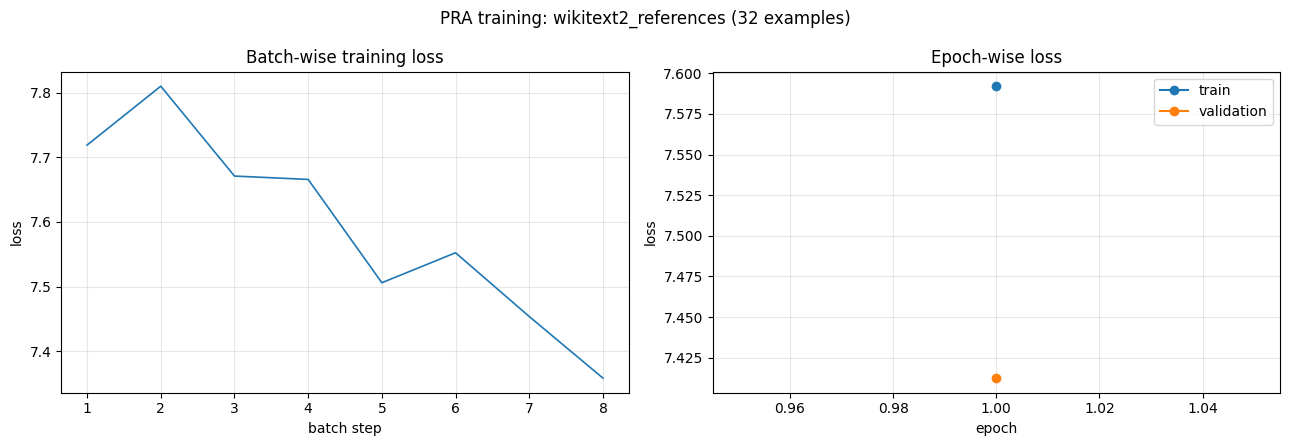

{'train_batches': 8,
 'train_epochs': 1,
 'validation_epochs': 1,
 'metrics_path': WindowsPath('D:/git/rd/pdattention/out/notebook_wikitext_refs/td_sa_tiny_wikitext2_refs_steps8_seq128/metrics.json'),
 'image_path': None}

In [5]:
progress = pnu.plot_training_progress(training_result, write_to_disk=False)
progress

## Reference-Aware Evaluation

In [6]:
evaluation_results = pnu.evaluate_trained_workload(training_result, max_new_tokens=8)

PRA eval report (checkpoint)
variant       loss     accuracy   input_tokens   resolved_refs   ref_hit   anchor_hit   cache_hit   latency
no_refs        7.388   0.00%           37.2             0.0    0.00%       0.00%      0.00%    0.230s
full_context   7.388   0.00%          149.8             0.0    0.00%       0.00%      0.00%    0.224s
simple_rag     7.388   0.00%          113.0             0.0    0.00%       0.00%      0.00%    0.212s
pra            7.388   0.00%           37.2             3.5  100.00%     100.00%    100.00%    0.246s

Sample PRA output:
<REF_1><REF_2><REF_3><REF_4><REF_5>, but the landing sector is a rectangular section surrounded by netting 17ly next July claithe interear


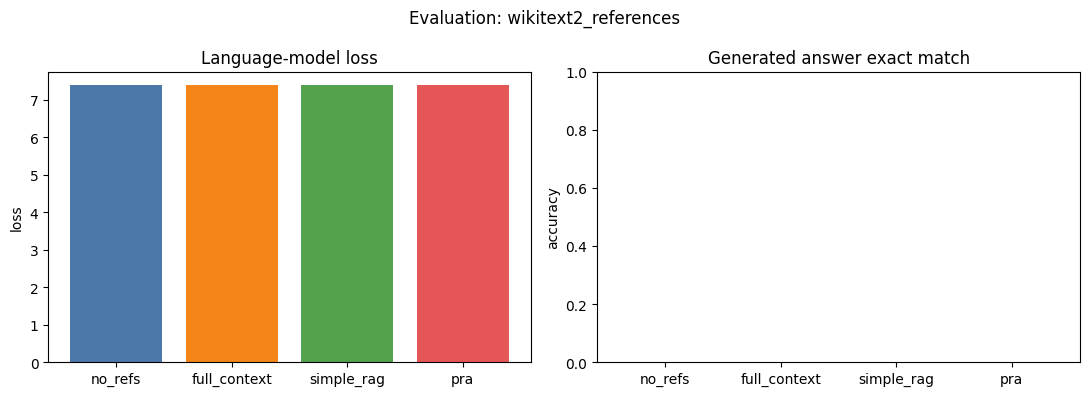

{'no_refs': 0.0, 'full_context': 0.0, 'simple_rag': 0.0, 'pra': 0.0}

In [7]:
evaluation_accuracy = pnu.plot_evaluation(evaluation_results, training_result, write_to_disk=False)
evaluation_accuracy

## HTML Experiment Report

In [8]:
report_path = pnu.generate_html_report(
    training_result,
    runtime=runtime,
    evaluation_results=evaluation_results,
    dataset_details=training_result["loader_summary"],
    model_name=training_result["model_name"],
    qualifiers=(f"steps{training_result['global_step']}", f"seq{training_result['policy'].max_seq_len}"),
)
report_path

wrote HTML report: D:\git\rd\pdattention\out\reports\td_sa_tiny_wikitext2_references_steps8_seq128\index.html


WindowsPath('D:/git/rd/pdattention/out/reports/td_sa_tiny_wikitext2_references_steps8_seq128/index.html')